<a href="https://colab.research.google.com/github/nvquockhanh29-ui/nvquockhanh29/blob/main/H%E1%BB%8CC_S%C3%82U.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
# Đọc file CSV, chú ý dấu phân cách là ';' và dấu thập phân là ','
df = pd.read_csv('/content/slump_test_data1.csv', sep=';', decimal=',')

# Loại bỏ cột 'No' vì chỉ là số thứ tự không có giá trị dự đoán
df = df.drop('No', axis=1)

# Tách biến đầu vào (X) và biến mục tiêu (y)
# Các cột từ Cement đến Fine Aggr là X, Cột Compressive Strength là y
X = df.iloc[:, :7].values  # 7 features đầu vào
y = df['Compressive Strength (28-day)(Mpa)'].values.reshape(-1, 1) # Mục tiêu dự đoán

# Chia dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (rất quan trọng trong Deep Learning giúp hội tụ nhanh hơn)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Chuyển đổi numpy arrays thành PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Tạo DataLoader để xử lý dữ liệu theo batch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)

# ==========================================
# 2. XÂY DỰNG MÔ HÌNH MẠNG NƠ-RON
# ==========================================
class ConcreteStrengthNet(nn.Module):
    def __init__(self, input_size):
        super(ConcreteStrengthNet, self).__init__()
        # Lớp ẩn 1: Nhận input_size, đầu ra 64 nơ-ron
        self.layer1 = nn.Linear(input_size, 64)
        # Hàm kích hoạt ReLU
        self.relu1 = nn.ReLU()
        # Lớp ẩn 2: Đầu vào 64, đầu ra 32
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        # Lớp ẩn 3: Đầu vào 32, đầu ra 16
        self.layer3 = nn.Linear(32, 16)
        self.relu3 = nn.ReLU()
        # Lớp đầu ra: Đầu vào 16, đầu ra 1 (dự đoán cường độ)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu1(out)
        out = self.layer2(out)
        out = self.relu2(out)
        out = self.layer3(out)
        out = self.relu3(out)
        out = self.output_layer(out)
        return out

# Khởi tạo mô hình với input_size = 7
model = ConcreteStrengthNet(input_size=7)

# ==========================================
# 3. CẤU HÌNH HUẤN LUYỆN (TRAINING)
# ==========================================
# Hàm mất mát MSE (Mean Squared Error) dành cho bài toán hồi quy
criterion = nn.MSELoss()
# Thuật toán tối ưu Adam với learning rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Số vòng lặp huấn luyện (epochs)
num_epochs = 200

print("Bắt đầu huấn luyện mô hình...\n")
for epoch in range(num_epochs):
    model.train() # Đặt mô hình ở chế độ huấn luyện
    epoch_loss = 0.0

    for inputs, labels in train_loader:
        # Xóa gradient của các biến tối ưu hóa
        optimizer.zero_grad()

        # Truyền tiến (Forward pass)
        outputs = model(inputs)

        # Tính sai số (Loss)
        loss = criterion(outputs, labels)

        # Truyền ngược (Backward pass)
        loss.backward()

        # Cập nhật trọng số
        optimizer.step()

        epoch_loss += loss.item()

    # In kết quả sau mỗi 20 epochs
    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}')

# ==========================================
# 4. ĐÁNH GIÁ MÔ HÌNH
# ==========================================
model.eval() # Đặt mô hình ở chế độ đánh giá
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = criterion(test_predictions, y_test_tensor)
    print(f'\nMSE trên tập kiểm tra (đã chuẩn hóa): {test_loss.item():.4f}')

    # Đưa kết quả dự đoán về lại thang đo gốc để dễ so sánh
    y_pred_original = scaler_y.inverse_transform(test_predictions.numpy())
    y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy())

    print("\nMột vài mẫu so sánh (Thực tế vs Dự đoán):")
    for i in range(5):
        print(f"Thực tế: {y_test_original[i][0]:.2f} MPa | Dự đoán: {y_pred_original[i][0]:.2f} MPa")

Bắt đầu huấn luyện mô hình...

Epoch [20/200], Loss: 0.0499
Epoch [40/200], Loss: 0.0122
Epoch [60/200], Loss: 0.0035
Epoch [80/200], Loss: 0.0022
Epoch [100/200], Loss: 0.0033
Epoch [120/200], Loss: 0.0013
Epoch [140/200], Loss: 0.0025
Epoch [160/200], Loss: 0.0006
Epoch [180/200], Loss: 0.0005
Epoch [200/200], Loss: 0.0004

MSE trên tập kiểm tra (đã chuẩn hóa): 0.0127

Một vài mẫu so sánh (Thực tế vs Dự đoán):
Thực tế: 45.82 MPa | Dự đoán: 47.44 MPa
Thực tế: 40.34 MPa | Dự đoán: 41.64 MPa
Thực tế: 28.29 MPa | Dự đoán: 28.66 MPa
Thực tế: 43.01 MPa | Dự đoán: 42.16 MPa
Thực tế: 33.51 MPa | Dự đoán: 34.67 MPa



PHÂN TÍCH ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
Sai số tuyệt đối trung bình (MAE): 0.75 MPa
Độ phù hợp của mô hình (R2 Score): 0.9842 (Giá trị càng gần 1, mô hình dự đoán càng chuẩn)


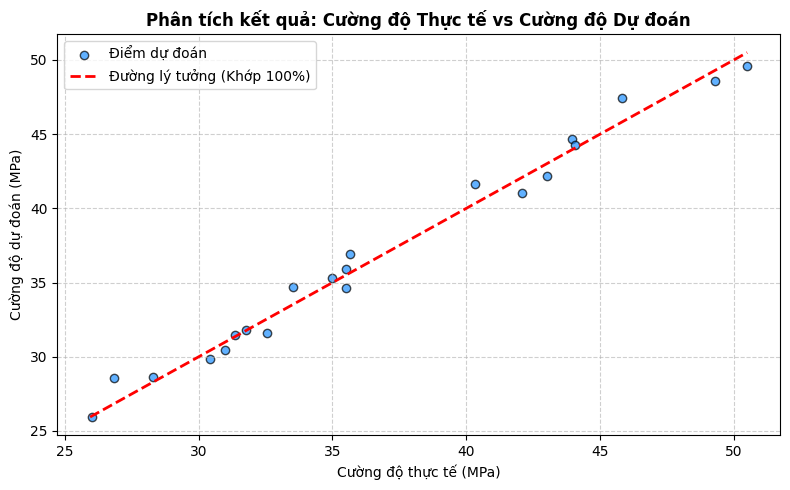


TEST DỰ ĐOÁN VỚI MẺ BÊ TÔNG MỚI
Thông số đầu vào:
- Xi măng: 250 | Xỉ: 100 | Tro bay: 50 | Nước: 190
- SP: 10 | Cốt liệu thô: 850 | Cốt liệu mịn: 750
-> AI DỰ ĐOÁN CƯỜNG ĐỘ (28 NGÀY): 33.65 MPa



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# 5. PHÂN TÍCH VÀ ĐÁNH GIÁ CHI TIẾT
# ==========================================
print("\n" + "="*40)
print("PHÂN TÍCH ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST")
print("="*40)

model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)

# Đưa kết quả về thang đo thực tế gốc
y_pred = scaler_y.inverse_transform(test_predictions.numpy())
y_true = scaler_y.inverse_transform(y_test_tensor.numpy())

# Tính các chỉ số phân tích
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Sai số tuyệt đối trung bình (MAE): {mae:.2f} MPa")
print(f"Độ phù hợp của mô hình (R2 Score): {r2:.4f} (Giá trị càng gần 1, mô hình dự đoán càng chuẩn)")

# Vẽ biểu đồ trực quan (Thực tế vs Dự đoán)
plt.figure(figsize=(8, 5))
plt.scatter(y_true, y_pred, color='dodgerblue', alpha=0.7, edgecolors='k', label='Điểm dự đoán')

# Vẽ đường thẳng lý tưởng y = x (Dự đoán khớp 100% với thực tế)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường lý tưởng (Khớp 100%)')

plt.title('Phân tích kết quả: Cường độ Thực tế vs Cường độ Dự đoán', fontsize=12, fontweight='bold')
plt.xlabel('Cường độ thực tế (MPa)', fontsize=10)
plt.ylabel('Cường độ dự đoán (MPa)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ==========================================
# 6. HÀM DÙNG THỬ (TEST) VỚI THÔNG SỐ TỰ NHẬP
# ==========================================
def predict_new_mix(cement, slag, fly_ash, water, sp, coarse, fine):
    """
    Hàm này cho phép sếp nhập vào một công thức trộn mới và dự đoán kết quả.
    """
    print("\n" + "="*40)
    print("TEST DỰ ĐOÁN VỚI MẺ BÊ TÔNG MỚI")
    print("="*40)

    # Tạo mảng chứa 7 thông số đầu vào
    new_data = np.array([[cement, slag, fly_ash, water, sp, coarse, fine]])

    # CHÚ Ý: Phải dùng scaler_X đã huấn luyện ở trên để chuẩn hóa dữ liệu mới này
    new_data_scaled = scaler_X.transform(new_data)
    new_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

    # Bật chế độ suy luận và dự đoán
    model.eval()
    with torch.no_grad():
        pred_scaled = model(new_tensor)

    # Chuyển kết quả dự đoán về đơn vị thực tế (MPa)
    pred_real = scaler_y.inverse_transform(pred_scaled.numpy())

    print(f"Thông số đầu vào:")
    print(f"- Xi măng: {cement} | Xỉ: {slag} | Tro bay: {fly_ash} | Nước: {water}")
    print(f"- SP: {sp} | Cốt liệu thô: {coarse} | Cốt liệu mịn: {fine}")
    print(f"-> AI DỰ ĐOÁN CƯỜNG ĐỘ (28 NGÀY): {pred_real[0][0]:.2f} MPa\n")

# -- CHẠY THỬ HÀM TEST --
# Thông số giả định: Xi măng 250, Xỉ 100, Tro 50, Nước 190, SP 10, Cốt thô 850, Cốt mịn 750
predict_new_mix(cement=250, slag=100, fly_ash=50, water=190, sp=10, coarse=850, fine=750)

# Sếp có thể copy dòng trên và thay đổi số liệu để test thoải mái nhé!